Vendor flagging is a concept used in procurement, accounting, and data systems where a vendor (supplier) is marked (or “flagged”) based on certain conditions.

✅ Simple Meaning

Vendor flagging = tagging a vendor for attention or action
basically the objectiuve of this is to flag the suspicious invoices and undergo through manual checking of it .. for eg if the freight cost is 2000 but normally its 500 then it flgas it as suspicious and undergoes manual checking so it prevents fraud,overpayment and billing mistakes

Flagging Vendor Invoices for Manual Review
Objective: Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

Manual invoice review is time-consuming and does not scale with transaction volume.

Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.

An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [66]:
import pandas as pd
import sqlite3
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [67]:
conn=sqlite3.connect('../data/inventory (4).db')

In [68]:
tables=pd.read_sql_query("select name from sqlite_master where type='table'",conn)
for table in tables['name']:
    print("Table name:",table)
    display(pd.read_sql_query(f"select * from {table} limit 5",conn))

Table name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [69]:
puchase_agg_df=pd.read_sql_query("""select 
                  p.PONumber,
                  count(distinct p.Brand)as total_brands,
                  sum(p.Quantity) as total_quantity,
                  sum(p.Dollars) as total_dollars,
                  avg(julianday(p.ReceivingDate)-julianday(p.PODate)) as avg_recieving_delay
                  from purchases p 
group by p.PONumber""",conn)

In [70]:
#julianday(date) converts a date into a numeric value (number of days).
#How long vendor took to generate invoice after order
#Payment delay time
pd.read_sql_query("""
select 
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_Dollars,
vi.Freight as Freight,
(julianday(vi.InvoiceDate)-julianday(vi.PODate))as days_to_pay_invoice, 
(julianday(vi.PayDate)-julianday(vi.InvoiceDate))as days_to_pay
from vendor_invoice vi
""",conn)

,invoice_quantity,invoice_Dollars,Freight,days_to_pay_invoice,days_to_pay
0,6,214.26,3.47,14.0,43.0
1,15,140.55,8.57,16.0,45.0
2,5,106.60,4.61,16.0,38.0
3,10100,137483.78,2935.20,23.0,24.0
4,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0
5539,4617,37300.48,186.50,18.0,39.0
5540,9848,202815.78,932.95,11.0,33.0
5541,24747,149007.56,819.54,14.0,36.0


In [71]:
#this is the final merged table on which w are going to peform our final analysis
df=pd.read_sql_query("""
with purchase_agg as (
select
p.PONumber,
                  count(distinct p.Brand)as total_brands,
                  sum(p.Quantity) as total_quantity,
                  sum(p.Dollars) as total_dollars,
                  avg(julianday(p.ReceivingDate)-julianday(p.PODate)) as avg_recieving_delay
                  from purchases p 
group by p.PONumber
)

select 
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_Dollars,
vi.Freight as Freight,
(julianday(vi.InvoiceDate)-julianday(vi.PODate))as days_to_pay_invoice, 
(julianday(vi.PayDate)-julianday(vi.InvoiceDate))as days_to_pay,
pa.total_brands,
pa.total_quantity,
pa.total_dollars,
pa.avg_recieving_delay
from vendor_invoice vi
left join purchase_agg pa 
on vi.PONumber=pa.PONumber

""",conn)

In [72]:
df

,invoice_quantity,invoice_Dollars,Freight,days_to_pay_invoice,days_to_pay,total_brands,total_quantity,total_dollars,avg_recieving_delay
0,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [73]:
df.isnull().sum()

invoice_quantity       0
invoice_Dollars        0
Freight                0
days_to_pay_invoice    0
days_to_pay            0
total_brands           0
total_quantity         0
total_dollars          0
avg_recieving_delay    0
dtype: int64

In [74]:
df.dtypes

invoice_quantity         int64
invoice_Dollars        float64
Freight                float64
days_to_pay_invoice    float64
days_to_pay            float64
total_brands             int64
total_quantity           int64
total_dollars          float64
avg_recieving_delay    float64
dtype: object

In [75]:
#as we can see there is no label in our dataset so to fit supervised learning model we need the labels to train our model so lets create labels
#lets crete a rule based system that will decide 1 means risky invoice and 0 means normal invoice 
def create_invoice_risk_label(row):
    if (abs(row["invoice_Dollars"] - row["total_dollars"]) > 5): #checking if the total bill on the invoice is greter than the individual item price if the difference is too much thn raise a flag because the total bill contains freight+gst included so the amount may increse significantly but too much increase may lead to hidden fraud/error or billing mistake
        return 1
    if row["avg_recieving_delay"] > 10:
        return 1
    return 0
df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()
    

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

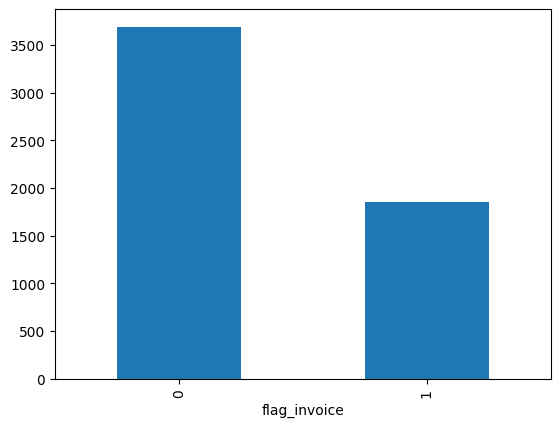

In [94]:
df['flag_invoice'].value_counts().plot(kind='bar')

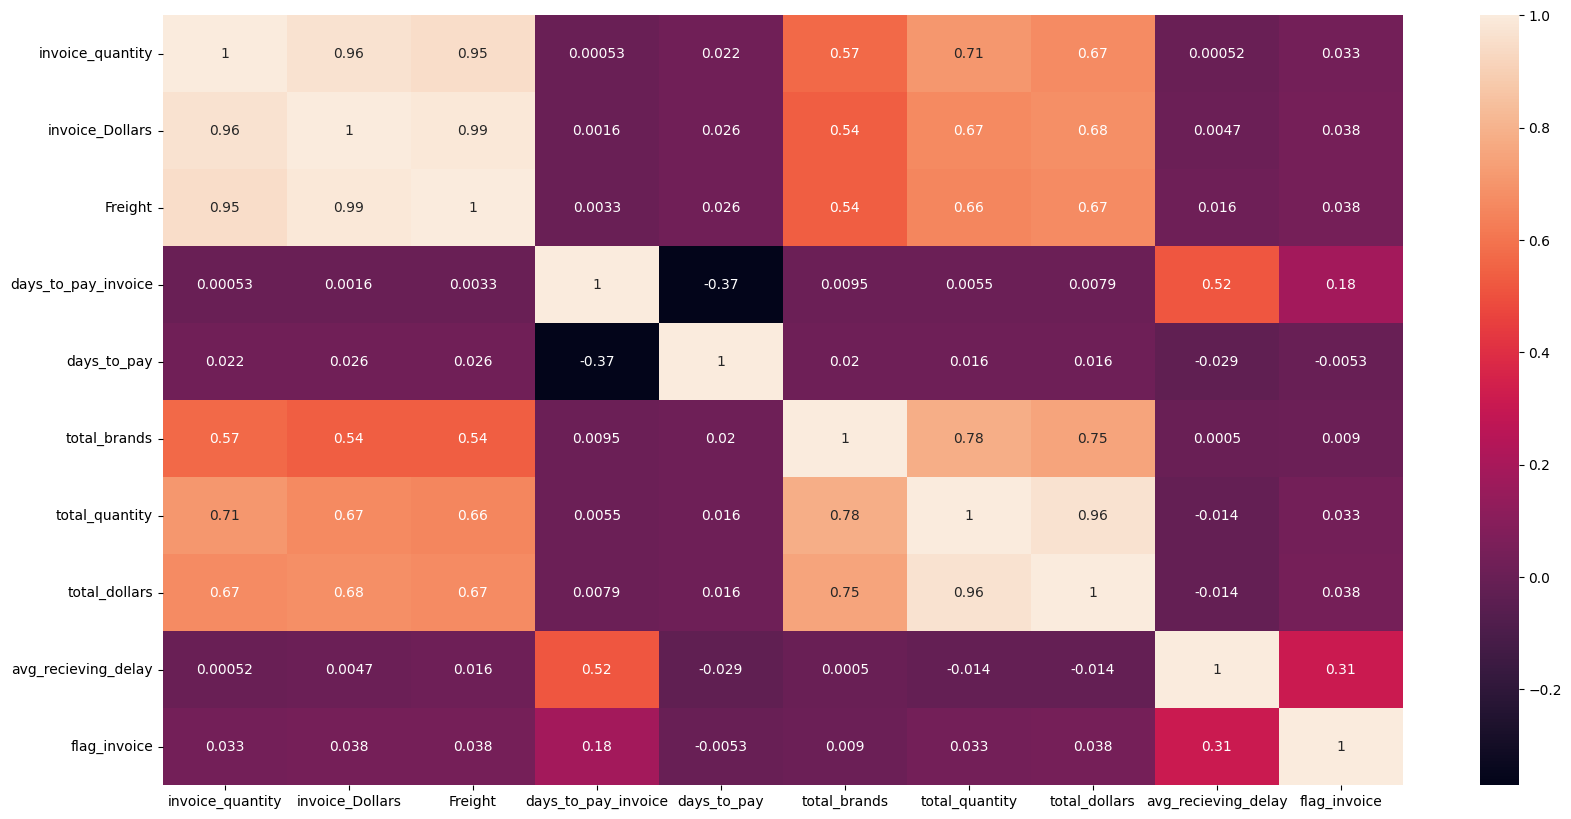

In [95]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [96]:
df

,invoice_quantity,invoice_Dollars,Freight,days_to_pay_invoice,days_to_pay,total_brands,total_quantity,total_dollars,avg_recieving_delay,flag_invoice
0,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000,1
1,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333,1
2,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000,0
3,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130,1
4,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809,0
...,...,...,...,...,...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795,1
5539,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500,1
5540,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000,1
5541,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541,1


In [97]:
flagged=df[df['flag_invoice']==1]
normal=df[df['flag_invoice']==0]

In [98]:
#Population standard deviation measures variability across the entire population, but it is usually unknown because we only have access to sample data.”
#most of the time we dont have access to the entire(population) data and we wok with the sample data so when we dont know thr std of the population we make use of t test and when we know the population data we make use of z test 
significant_features=[]
non_significant_features=[]
results=[]
metrics=['invoice_quantity','invoice_Dollars','Freight','days_to_pay_invoice','days_to_pay','total_brands','total_quantity','total_dollars','avg_recieving_delay']

In [99]:
from scipy.stats import ttest_ind
for metric in metrics:
    flagged_mean=flagged[metric].mean()
    normal_mean=normal[metric].mean()

    t_stats,p_value=ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False #The two groups are assumed to have unequal variance (this is a safer assumption).

    )
    if p_value<0.05:
        significant_features.append(metric)
        results.append({
            "metric":metric,
            "flagged_mean":flagged_mean.round(2),
            "normal_mean":normal_mean.round(2),
            "p_value":p_value.round(3)
        })
    else:
        non_significant_features.append(metric)
    

In [100]:
non_significant_features

['days_to_pay', 'total_brands']

In [101]:
significant_features

['invoice_quantity',
 'invoice_Dollars',
 'Freight',
 'days_to_pay_invoice',
 'total_quantity',
 'total_dollars',
 'avg_recieving_delay']

In [102]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': 6728.28,
  'normal_mean': 5723.55,
  'p_value': 0.021},
 {'metric': 'invoice_Dollars',
  'flagged_mean': 65600.61,
  'normal_mean': 54302.64,
  'p_value': 0.008},
 {'metric': 'Freight',
  'flagged_mean': 334.02,
  'normal_mean': 276.89,
  'p_value': 0.008},
 {'metric': 'days_to_pay_invoice',
  'flagged_mean': 17.23,
  'normal_mean': 16.02,
  'p_value': 0.0},
 {'metric': 'total_quantity',
  'flagged_mean': 6728.28,
  'normal_mean': 5723.55,
  'p_value': 0.021},
 {'metric': 'total_dollars',
  'flagged_mean': 65600.61,
  'normal_mean': 54302.64,
  'p_value': 0.008},
 {'metric': 'avg_recieving_delay',
  'flagged_mean': 8.47,
  'normal_mean': 7.27,
  'p_value': 0.0}]

In [103]:
X=df[['invoice_quantity',
 'invoice_Dollars',
 'Freight',
 'days_to_pay_invoice',
 'total_quantity',
 'total_dollars',
 'avg_recieving_delay']]
y=df['flag_invoice']

In [104]:
X.describe().round()

,invoice_quantity,invoice_Dollars,Freight,days_to_pay_invoice,total_quantity,total_dollars,avg_recieving_delay
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,6059.0,58073.0,8.0
std,14453.0,140234.0,714.0,3.0,14453.0,140234.0,2.0
min,1.0,4.0,0.0,9.0,1.0,4.0,3.0
25%,83.0,968.0,5.0,14.0,83.0,968.0,6.0
50%,423.0,4765.0,25.0,16.0,423.0,4765.0,8.0
75%,5100.0,44587.0,230.0,19.0,5100.0,44587.0,9.0
max,141660.0,1660436.0,8468.0,23.0,141660.0,1660436.0,13.0


In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [106]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [107]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [108]:
model1=LogisticRegression()
model1.fit(X_train_scaled,y_train)

model2=DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled,y_train)

model3=RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [109]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    
    print(f"\n{model_name} Performance:")
    print(f"Accuracy : {acc:.2f}\n")

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

In [110]:
evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model2, X_test_scaled, y_test, 'Decision_Tree_Classifier')
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


Logistic Regression Performance:
Accuracy : 0.74

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.92      0.82       725
           1       0.72      0.39      0.50       384

    accuracy                           0.74      1109
   macro avg       0.73      0.65      0.66      1109
weighted avg       0.73      0.74      0.71      1109

Confusion Matrix:
[[668  57]
 [236 148]]

Decision_Tree_Classifier Performance:
Accuracy : 0.66

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.57      0.69       725
           1       0.51      0.83      0.63       384

    accuracy                           0.66      1109
   macro avg       0.69      0.70      0.66      1109
weighted avg       0.74      0.66      0.67      1109

Confusion Matrix:
[[416 309]
 [ 65 319]]

Random Forest Classifier Performance:
Accuracy : 0.65

Classification Report:
              precision    recal

In [117]:
model3.feature_importances_

array([0.10668727, 0.10055568, 0.10323929, 0.02603186, 0.15331893,
       0.20578767, 0.3043793 ])

In [118]:
feature_importance=pd.DataFrame({
    "feature":X_train.columns,
    "importance":model3.feature_importances_
}).sort_values(by='importance',ascending=False)
feature_importance

,feature,importance
6,avg_recieving_delay,0.304379
5,total_dollars,0.205788
4,total_quantity,0.153319
0,invoice_quantity,0.106687
2,Freight,0.103239
1,invoice_Dollars,0.100556
3,days_to_pay_invoice,0.026032


In [119]:
#based on thisimportance we can remove the least important columns and then again train the model 
X=df[['invoice_quantity',
 
 'Freight',
 
 'total_quantity',
 'total_dollars',
 'avg_recieving_delay']]
y=df['flag_invoice']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model1=LogisticRegression()
model1.fit(X_train_scaled,y_train)

model2=DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled,y_train)

model3=RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled,y_train)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    
    print(f"\n{model_name} Performance:")
    print(f"Accuracy : {acc:.2f}\n")

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model2, X_test_scaled, y_test, 'Decision_Tree_Classifier')
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


Logistic Regression Performance:
Accuracy : 0.74

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.92      0.82       725
           1       0.72      0.39      0.50       384

    accuracy                           0.74      1109
   macro avg       0.73      0.65      0.66      1109
weighted avg       0.73      0.74      0.71      1109

Confusion Matrix:
[[668  57]
 [236 148]]

Decision_Tree_Classifier Performance:
Accuracy : 0.66

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.57      0.69       725
           1       0.51      0.83      0.63       384

    accuracy                           0.66      1109
   macro avg       0.69      0.70      0.66      1109
weighted avg       0.74      0.66      0.67      1109

Confusion Matrix:
[[416 309]
 [ 65 319]]

Random Forest Classifier Performance:
Accuracy : 0.65

Classification Report:
              precision    recal

In [120]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ['gini', 'entropy']
}

In [123]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ['gini', 'entropy']
}

scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search, X_test_scaled, y_test, 'Random Forest Classifier')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Random Forest Classifier Performance:
Accuracy : 0.64

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.54      0.66       725
           1       0.49      0.83      0.62       384

    accuracy                           0.64      1109
   macro avg       0.67      0.69      0.64      1109
weighted avg       0.73      0.64      0.65      1109

Confusion Matrix:
[[392 333]
 [ 64 320]]


In [130]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, grid_search.predict(X_test_scaled))

array([[392, 333],
       [ 64, 320]], dtype=int64)